In [101]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt
import random
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2


In [102]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [103]:
data = pd.read_csv('GDP_forecasting data.csv')

In [104]:
data.shape



(271, 246)

In [105]:
data.head()

,sasdate,GDPC1,PCECC96,PCDGx,PCESVx,PCNDx,GPDIC1,FPIx,Y033RC1Q027SBEAx,PNFIx,...,TNWMVBSNNCBBDIx,TLBSNNBx,TLBSNNBBDIx,TABSNNBx,TNWBSNNBx,TNWBSNNBBDIx,CNCFx,S&P 500,S&P div yield,S&P PE ratio
0,factors,0.000,0.000,1.0000,1.0000,1.0000,0.000,0.0000,1.0000,1.0000,...,0.00,0.0,0.0,0.000000e+00,0.00,0.00,0.0000,1.0000,0.0000,0.0000
1,transform,5.000,5.000,5.0000,5.0000,5.0000,5.000,5.0000,5.0000,5.0000,...,2.00,5.0,1.0,5.000000e+00,5.00,2.00,5.0000,5.0000,2.0000,5.0000
2,3/1/1959,3352.129,2039.017,68.6651,1374.1739,689.1172,354.894,357.0174,47.8021,171.0783,...,1341691.84,333239846.8,266663789.4,2.426352e+09,2092540.86,1674484.25,124.9663,55.5167,3.1765,18.6211
3,6/1/1959,3427.667,2070.508,71.2495,1394.7096,694.8197,382.500,368.0640,49.2332,176.0004,...,1294173.52,345855787.9,273337876.4,2.434981e+09,2088548.18,1650628.22,126.5305,57.5067,3.1012,19.2899
4,9/1/1959,3430.057,2092.138,72.6270,1413.6627,697.4699,357.798,371.9585,50.8372,180.7406,...,1320742.77,354813422.8,275143642.3,2.434604e+09,2079200.00,1612336.58,128.9557,58.7300,3.0720,18.9544


**Save the transfomation information in the form of a dictionary**


In [106]:
transforms_metadata = data.iloc[1].drop("sasdate").astype(float).to_dict()

In [107]:
transforms_metadata

{'GDPC1': 5.0,
 'PCECC96': 5.0,
 'PCDGx': 5.0,
 'PCESVx': 5.0,
 'PCNDx': 5.0,
 'GPDIC1': 5.0,
 'FPIx': 5.0,
 'Y033RC1Q027SBEAx': 5.0,
 'PNFIx': 5.0,
 'PRFIx': 5.0,
 'A014RE1Q156NBEA': 1.0,
 'GCEC1': 5.0,
 'A823RL1Q225SBEA': 1.0,
 'FGRECPTx': 5.0,
 'SLCEx': 5.0,
 'EXPGSC1': 5.0,
 'IMPGSC1': 5.0,
 'DPIC96': 5.0,
 'OUTNFB': 5.0,
 'OUTBS': 5.0,
 'OUTMS': 5.0,
 'INDPRO': 5.0,
 'IPFINAL': 5.0,
 'IPCONGD': 5.0,
 'IPMAT': 5.0,
 'IPDMAT': 5.0,
 'IPNMAT': 5.0,
 'IPDCONGD': 5.0,
 'IPB51110SQ': 5.0,
 'IPNCONGD': 5.0,
 'IPBUSEQ': 5.0,
 'IPB51220SQ': 5.0,
 'TCU': 1.0,
 'CUMFNS': 1.0,
 'PAYEMS': 5.0,
 'USPRIV': 5.0,
 'MANEMP': 5.0,
 'SRVPRD': 5.0,
 'USGOOD': 5.0,
 'DMANEMP': 5.0,
 'NDMANEMP': 5.0,
 'USCONS': 5.0,
 'USEHS': 5.0,
 'USFIRE': 5.0,
 'USINFO': 5.0,
 'USPBS': 5.0,
 'USLAH': 5.0,
 'USSERV': 5.0,
 'USMINE': 5.0,
 'USTPU': 5.0,
 'USGOVT': 5.0,
 'USTRADE': 5.0,
 'USWTRADE': 5.0,
 'CES9091000001': 5.0,
 'CES9092000001': 5.0,
 'CES9093000001': 5.0,
 'CE16OV': 5.0,
 'CIVPART': 2.0,
 'UNRATE': 2.0,

In [108]:
data_wf = data.iloc[2:].copy()

In [109]:
data_wf.shape

(269, 246)

**Setting date as index**

In [110]:
data_wf["sasdate"] = pd.to_datetime(data_wf["sasdate"])
data_wf = data_wf.set_index("sasdate")

In [111]:
#Checking if the entire data is in the form of numerical values rather than string.
for col in data_wf.columns:
    data_wf[col] = pd.to_numeric(data_wf[col], errors="coerce")

In [112]:
#finding the percentage of missing values
missing_percentage = data_wf.isna().mean()
missing_percentage

,0
GDPC1,0.000000
PCECC96,0.000000
PCDGx,0.000000
PCESVx,0.000000
PCNDx,0.000000
...,...
TNWBSNNBBDIx,0.003717
CNCFx,0.003717
S&P 500,0.000000
S&P div yield,0.000000


**Removing the columns that has more than threshold missing values**

In [113]:
# we identify the columns to be removed using a threshold net and store the column names in a list
sparsity_threshold = 0.1
columns_to_keep = (missing_percentage[missing_percentage <= sparsity_threshold].index.tolist())
sparsity_dropped = (missing_percentage[missing_percentage > sparsity_threshold].index.tolist())

print(len(columns_to_keep))
print(len(sparsity_dropped))

217
28


In [114]:
columns_to_keep

['GDPC1',
 'PCECC96',
 'PCDGx',
 'PCESVx',
 'PCNDx',
 'GPDIC1',
 'FPIx',
 'Y033RC1Q027SBEAx',
 'PNFIx',
 'PRFIx',
 'A014RE1Q156NBEA',
 'GCEC1',
 'A823RL1Q225SBEA',
 'FGRECPTx',
 'SLCEx',
 'EXPGSC1',
 'IMPGSC1',
 'DPIC96',
 'OUTNFB',
 'OUTBS',
 'INDPRO',
 'IPFINAL',
 'IPCONGD',
 'IPMAT',
 'IPDMAT',
 'IPNMAT',
 'IPDCONGD',
 'IPB51110SQ',
 'IPNCONGD',
 'IPBUSEQ',
 'IPB51220SQ',
 'CUMFNS',
 'PAYEMS',
 'USPRIV',
 'MANEMP',
 'SRVPRD',
 'USGOOD',
 'DMANEMP',
 'NDMANEMP',
 'USCONS',
 'USEHS',
 'USFIRE',
 'USINFO',
 'USPBS',
 'USLAH',
 'USSERV',
 'USMINE',
 'USTPU',
 'USGOVT',
 'USTRADE',
 'USWTRADE',
 'CES9091000001',
 'CES9092000001',
 'CES9093000001',
 'CE16OV',
 'CIVPART',
 'UNRATE',
 'UNRATESTx',
 'UNRATELTx',
 'LNS14000012',
 'LNS14000025',
 'LNS14000026',
 'UEMPLT5',
 'UEMP5TO14',
 'UEMP15T26',
 'UEMP27OV',
 'LNS12032194',
 'HOABS',
 'HOANBS',
 'AWHMAN',
 'AWHNONAG',
 'AWOTMAN',
 'HWIx',
 'HOUST',
 'HOUST5F',
 'PERMIT',
 'HOUSTMW',
 'HOUSTNE',
 'HOUSTS',
 'HOUSTW',
 'CMRMTSPLx',
 'RSAFSx

In [115]:
sparsity_dropped

['OUTMS',
 'TCU',
 'LNS13023621',
 'LNS13023557',
 'LNS13023705',
 'LNS13023569',
 'HOAMS',
 'ACOGNOx',
 'ANDENOx',
 'INVCQRMTSPL',
 'WPU0531',
 'COMPRMS',
 'OPHMFG',
 'ULCMFG',
 'MORTGAGE30US',
 'MORTG10YRx',
 'REVOLSLx',
 'DRIWCIL',
 'USSTHPI',
 'SPCS10RSA',
 'SPCS20RSA',
 'TWEXAFEGSMTHx',
 'EXUSEU',
 'USEPUINDXM',
 'GFDEGDQ188S',
 'GFDEBTNx',
 'NASDAQCOM',
 'CUSR0000SEHC']

In [116]:
clean_timeline_df = data_wf[columns_to_keep].copy()

In [117]:
missing_counts = clean_timeline_df.isna().sum().sort_values(ascending=False)
to_be_filled = missing_counts[missing_counts > 0]
to_be_filled



,0
AWHNONAG,20
AHETPIx,20
VIXCLSx,14
PERMIT,4
PERMITMW,4
PERMITNE,4
PERMITS,4
PERMITW,4
UMCSENTx,2
TNWBSHNOx,1


**Removing the columns that  has very less missing values but they exist in long continuous blocks**

In [118]:
#since the data is absent in  the form of long bloacks and not randomly, we need to remove the colummns. Thus we are removing column
start_truncated_dropped = ["AWHNONAG", "AHETPIx", "VIXCLSx"]
clean_timeline_df = clean_timeline_df.drop(columns=start_truncated_dropped, errors="ignore")
all_dropped_columns = sparsity_dropped + start_truncated_dropped

#we will also drop the keys from the dictionary we made to store the transform values
for key in all_dropped_columns:
    transforms_metadata.pop(key, None)

**Filling missing values**

In [119]:
#filling the single missing values in columns using interpolation since this is a time series data
clean_filled_df = clean_timeline_df.interpolate(method="linear", limit_direction="both")



In [120]:
missing_counts = clean_filled_df.isna().sum().sort_values(ascending=False)
to_be_filled = missing_counts[missing_counts > 0]
to_be_filled

,0


**Transformation**

In [121]:
#since the data we are using are of different units we will need to transform the data. In the data which we are using, we are already provided with the transformation numbers which tells us how to transform the data.
#1 = Keep as is (No change)
#2 = First Difference
#3 = Second Difference
#4 = Natural Log
#5 = First Difference of Natural Log (Growth Rate)
#6 = Second Difference of Natural Log
#7 = Percentage Change

for col in clean_filled_df.columns:
    series = clean_filled_df[col]
    t_code = transforms_metadata.get(col, 1)

    if (t_code == 1):
        clean_filled_df[col] = series
    elif (t_code == 2):
        clean_filled_df[col] = series.diff()
    elif (t_code == 3):
        clean_filled_df[col] = series.diff().diff()
    elif (t_code == 4):
    # we apply the clipping because log can only take greater than zero values
        clean_filled_df[col] = np.log(series.clip(lower=1e-6))
    elif (t_code == 5):
        clean_filled_df[col] = np.log(series.clip(lower=1e-6)).diff()
    elif (t_code == 6):
        clean_filled_df[col] = np.log(series.clip(lower=1e-6)).diff().diff()
    elif (t_code == 7):
        clean_filled_df[col] = series.pct_change()

transformed_df = clean_filled_df.dropna(how="any")



**Segregating the GDP column**

In [122]:
target_column = 'GDPC1'
y_target = transformed_df[target_column].copy()
transformed_df = transformed_df.drop(columns=[target_column])

#splitting the GDP into train and test
split_idx = int(len(transformed_df) * 0.85)
y_train = y_target.iloc[:split_idx]
y_test = y_target.iloc[split_idx:]

**Grouping the features into economic sectors**

In [123]:
current_features = transformed_df.columns.tolist()

In [124]:
#We will define the 8 groups based on the factor number we were already provided in the data
groups = {
    "1_NIPA": [],
    "2_Industrial_Prod": [],
    "3_Labor_Market": [],
    "4_Housing": [],
    "5_Orders_Sales": [],
    "6_Prices": [],
    "7_Interest_Rates": [],
    "8_Money_Credit": []
}

#These groups stand for the following sectors
# National Income & Product Accounts (GDP, Consumption)
# Industrial Production & Capacity Utilization
# Employment, Unemployment, Hours Worked
# Housing Starts and Building Permits
# Manufacturing Orders, Retail Sales, Inventories
# CPI, PPI, and Inflation Gauges
# Fed Funds, Bond Yields, Yield Spreads
# Money Supply (M1/M2), Commercial Loans

for col in current_features:
    c = col.upper().strip()

    if any(x in c for x in ['GDP', 'PCE', 'OUT', 'INC', 'A0M', 'Y00', 'GPD', 'COMP']):
        groups["1_NIPA"].append(col)

    elif any(x in c for x in ['INDPRO', 'IPN', 'CUMF', 'CAP', 'UTIL', 'IP']):
        groups["2_Industrial_Prod"].append(col)

    elif any(x in c for x in ['UNRATE', 'EMP', 'PAY', 'HRS', 'WAGE', 'CEU', 'UEMP', 'MANEMP', 'JOB']):
        groups["3_Labor_Market"].append(col)

    elif any(x in c for x in ['HOUST', 'PERMIT', 'HS', 'CONSTR']):
        groups["4_Housing"].append(col)

    elif any(x in c for x in ['BUSINV', 'RETAIL', 'ORDER', 'SALES', 'UMCSENT', 'MOCM']):
        groups["5_Orders_Sales"].append(col)

    elif any(x in c for x in ['CPI', 'PPI', 'PCEPI', 'PRICE', 'DEFL', 'OILPRICE', 'SPOS']):
        groups["6_Prices"].append(col)

    elif any(x in c for x in ['FEDFUNDS', 'TBILL', 'YIELD', 'RATE', 'SPREAD', 'BAA', 'AAA', 'GS']):
        groups["7_Interest_Rates"].append(col)

    elif any(x in c for x in ['MONEY', 'M1', 'M2', 'LOAN', 'CREDIT', 'S&P', 'SP500', 'EXUS', 'BORR']):
        groups["8_Money_Credit"].append(col)
    else:
        if c.startswith('P'): groups["6_Prices"].append(col)
        elif c.startswith('R'): groups["5_Orders_Sales"].append(col)
        elif c.startswith('M'): groups["8_Money_Credit"].append(col)
        elif c.startswith('H'): groups["4_Housing"].append(col)
        else: groups["1_NIPA"].append(col)

**Splitting the data into train and test set**

In [125]:
#we will use slicing to split the data and we are doing this before the PCA analysis so to avoid the data leakage
#We will make a variable in order to split the data
train_raw_df = transformed_df.iloc[:split_idx]
test_raw_df = transformed_df.iloc[split_idx:]

**Using Block-PCA to reduce the columns to 8 columns based on the sector**

In [126]:
#we create a dictionary to store the final sectors
block_factors_dict = {}

train_factors_dict = {}
test_factors_dict = {}

#We run a loop to standardize the data seperately as train and test data
for group_name, col_list in groups.items():
    if len(col_list) > 0:
        train_block = train_raw_df[col_list]
        test_block = test_raw_df[col_list]

        scaler = StandardScaler()
        scaled_train = scaler.fit_transform(train_block)

        pca = PCA(n_components=1)
        train_factor = pca.fit_transform(scaled_train)

        scaled_test = scaler.transform(test_block)
        test_factor = pca.transform(scaled_test)

        train_factors_dict[f"{group_name}"] = train_factor.flatten()
        test_factors_dict[f"{group_name}"] = test_factor.flatten()

        exp_var = pca.explained_variance_ratio_[0] * 100
        print(f" {group_name:<20} , Train Variance Captured: {exp_var:.2f}%")


X_train_factors = pd.DataFrame(train_factors_dict, index=train_raw_df.index)
X_test_factors = pd.DataFrame(test_factors_dict, index=test_raw_df.index)

 1_NIPA               , Train Variance Captured: 17.33%
 2_Industrial_Prod    , Train Variance Captured: 51.60%
 3_Labor_Market       , Train Variance Captured: 63.48%
 4_Housing            , Train Variance Captured: 40.84%
 5_Orders_Sales       , Train Variance Captured: 33.16%
 6_Prices             , Train Variance Captured: 35.17%
 7_Interest_Rates     , Train Variance Captured: 40.76%
 8_Money_Credit       , Train Variance Captured: 27.37%


In [127]:
X_train_factors.head()

,1_NIPA,2_Industrial_Prod,3_Labor_Market,4_Housing,5_Orders_Sales,6_Prices,7_Interest_Rates,8_Money_Credit
sasdate,,,,,,,,
1959-09-01,-1.235660,-4.706586,1.101435,-0.597302,0.749362,-0.057327,2.056047,-0.491501
1959-12-01,-1.968420,-1.886005,1.214456,-0.614388,0.400005,-0.111292,1.259045,-1.636608
1960-03-01,5.462601,8.981068,-4.408065,-0.506045,1.975993,-0.342802,0.747536,-1.153410
1960-06-01,-2.099155,-3.351423,0.673299,-1.332051,-0.906991,-0.344303,-0.448900,-1.067186
1960-09-01,-5.064518,-3.948030,3.292465,-1.206709,-0.610256,-0.739121,-1.511494,0.432055


**Plotting the values of GDP to see the trend in data**

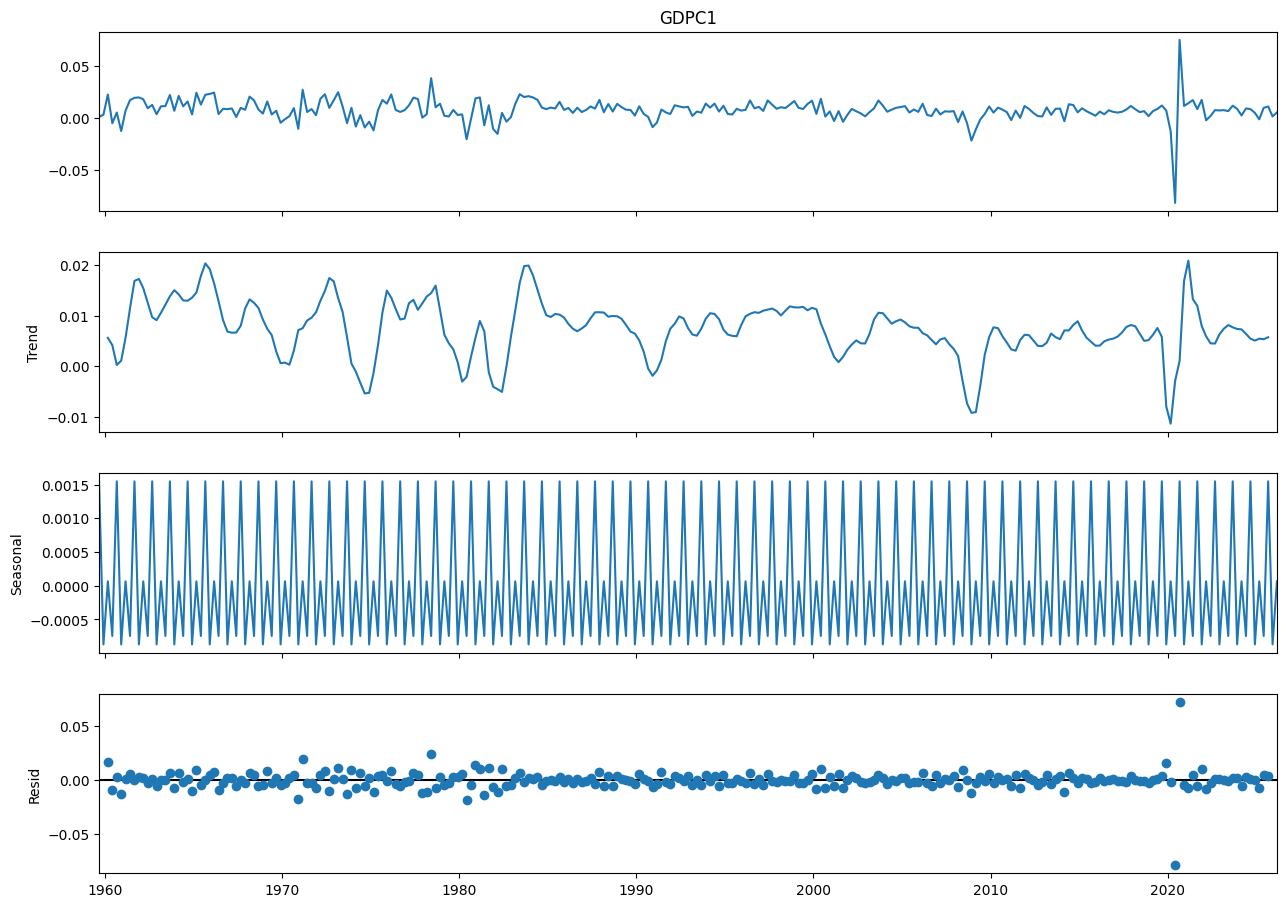

In [128]:
decomposition = seasonal_decompose(y_target, model='additive', period=4)
fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.show()

**The Augmented Dickey-Fuller Stationarity Check**

In [129]:
for col in X_train_factors.columns:
    series = X_train_factors[col]

    result = adfuller(series)
    adf_statistic = result[0]
    p_value = result[1]

    print(f" Feature Factor: {col:<30}")
    print(f" ADF Test Statistic: {adf_statistic:.4f}")
    print(f" p-value:            {p_value:.5f}")

    if p_value < 0.05:
        print("Stationary")
    else:
        print("Non-Stationary")

 Feature Factor: 1_NIPA                        
 ADF Test Statistic: -4.2060
 p-value:            0.00064
Stationary
 Feature Factor: 2_Industrial_Prod             
 ADF Test Statistic: -3.9393
 p-value:            0.00176
Stationary
 Feature Factor: 3_Labor_Market                
 ADF Test Statistic: -4.0909
 p-value:            0.00100
Stationary
 Feature Factor: 4_Housing                     
 ADF Test Statistic: -9.8272
 p-value:            0.00000
Stationary
 Feature Factor: 5_Orders_Sales                
 ADF Test Statistic: -3.6288
 p-value:            0.00523
Stationary
 Feature Factor: 6_Prices                      
 ADF Test Statistic: -11.1798
 p-value:            0.00000
Stationary
 Feature Factor: 7_Interest_Rates              
 ADF Test Statistic: -4.4666
 p-value:            0.00023
Stationary
 Feature Factor: 8_Money_Credit                
 ADF Test Statistic: -7.5466
 p-value:            0.00000
Stationary


In [130]:
#all our 8 sectors are stationary

**Using the GRU architecture to predict the time series data**

In [131]:
#feature here means the number of quarters that u have
def create_sequences(features, target, lookback_window=8):
    X_seq, y_seq = [], []
    for i in range(len(features) - lookback_window): #tell the number of times a loop will run
        X_seq.append(features.iloc[i : i + lookback_window].values)
        y_seq.append(target.iloc[i + lookback_window])
    return np.array(X_seq), np.array(y_seq)

lookback = 8
X_train_seq, y_train_seq = create_sequences(X_train_factors, y_train, lookback_window=lookback)
X_test_seq, y_test_seq = create_sequences(X_test_factors, y_test, lookback_window=lookback)

print(f"GRU Training Inputs Shape (Samples, Time Steps, Features): {X_train_seq.shape}")
print(f"GRU Training Targets Shape (Samples,)                    : {y_train_seq.shape}")
print(f"GRU Testing Inputs Shape  (Samples, Time Steps, Features): {X_test_seq.shape}")
print(f"GRU Testing Targets Shape  (Samples,)                    : {y_test_seq.shape}")

GRU Training Inputs Shape (Samples, Time Steps, Features): (218, 8, 8)
GRU Training Targets Shape (Samples,)                    : (218,)
GRU Testing Inputs Shape  (Samples, Time Steps, Features): (33, 8, 8)
GRU Testing Targets Shape  (Samples,)                    : (33,)


In [132]:
time_steps = X_train_seq.shape[1]
num_features = X_train_seq.shape[2]

model = Sequential([GRU(units=32, activation='tanh', input_shape=(time_steps, num_features), return_sequences=False), Dropout(0.4), Dense(units=16, activation='relu'), Dense(units=1)])

model.compile(optimizer='Adam', loss='huber', metrics=['mae'])
print(model.summary())
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,577 (17.88 KB)

 Trainable params: 4,577 (17.88 KB)

 Non-trainable params: 0 (0.00 B)

None


In [133]:
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=8,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.1129 - mae: 0.3396 - val_loss: 0.0768 - val_mae: 0.3282
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0585 - mae: 0.2485 - val_loss: 0.0557 - val_mae: 0.2711
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0401 - mae: 0.2077 - val_loss: 0.0547 - val_mae: 0.2861
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0323 - mae: 0.1820 - val_loss: 0.0454 - val_mae: 0.2497
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0247 - mae: 0.1627 - val_loss: 0.0355 - val_mae: 0.2217
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0326 - mae: 0.1847 - val_loss: 0.0347 - val_mae: 0.2219
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0169 - mae: 0.1394 - val_loss: 0.0322 - val_mae: 0.2122
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0167 - mae: 0.1382 - val_loss: 0.0326 - val_mae: 0.2161
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - los

In [134]:
predictions = model.predict(X_test_seq).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 330ms/step


**Using LSTM architecture**

In [161]:
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(units=16,
                         input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
                         return_sequences=False),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(units=1)
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='huber')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [162]:
early_stop_lstm = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)
lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=250,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0735 - val_loss: 0.0163
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0508 - val_loss: 0.0141
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0358 - val_loss: 0.0131
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0445 - val_loss: 0.0128
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0376 - val_loss: 0.0128
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0324 - val_loss: 0.0130
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0355 - val_loss: 0.0126
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0281 - val_loss: 0.0120
Epoch 9/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0246 - val_loss: 0.0116
Epoch 10/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0205 - val_loss: 0.0110
Epoch 11/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0231 - val_loss: 0.0108
Epoch 12/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0220 - val_l

In [163]:
lstm_predictions = lstm_model.predict(X_test_seq).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


In [164]:
gru_mse = mean_squared_error(y_test_seq, predictions)
lstm_mse = mean_squared_error(y_test_seq, lstm_predictions)
print(gru_mse)
print(lstm_mse)

0.0001364979562704996
0.0011271764443332329


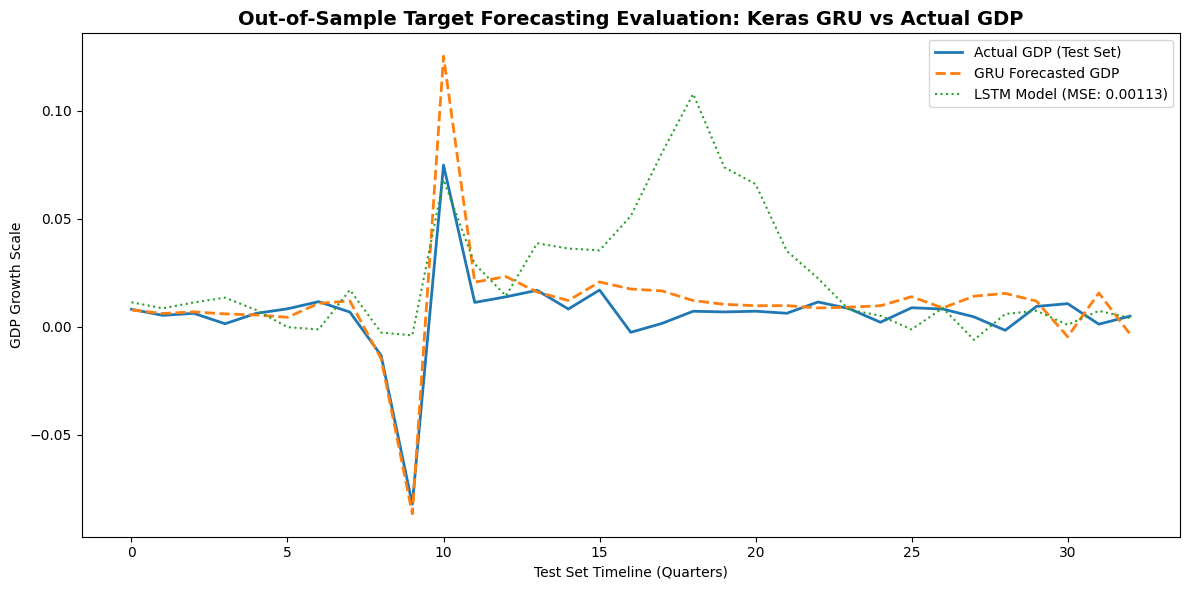

In [165]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_seq, label='Actual GDP (Test Set)', color='#1f77b4', linewidth=2)
plt.plot(predictions, label='GRU Forecasted GDP', color='#ff7f0e', linestyle='--', linewidth=2)
plt.plot(lstm_predictions, label=f'LSTM Model (MSE: {lstm_mse:.5f})', color='#2ca02c', linestyle=':')
plt.title('Out-of-Sample Target Forecasting Evaluation: Keras GRU vs Actual GDP', fontsize=14, fontweight='bold')
plt.xlabel('Test Set Timeline (Quarters)')
plt.ylabel('GDP Growth Scale')
plt.legend()
plt.tight_layout()
plt.show()

**Running a base line model to check for the efficiency of our GRU and LSTM model**

In [166]:
naive_predictions = y_test.iloc[lookback - 1 : len(y_test) - 1].values

In [167]:
actual_gdp = y_test_seq

In [168]:
baseline_mse = mean_squared_error(actual_gdp, naive_predictions)
gru_mse = mean_squared_error(actual_gdp, predictions)
lstm_mse = mean_squared_error(y_test_seq, lstm_predictions)

In [169]:
baseline_mae = mean_absolute_error(actual_gdp, naive_predictions)
gru_mae = mean_absolute_error(actual_gdp, predictions)
lstm_mae = mean_absolute_error(y_test_seq, lstm_predictions)

In [171]:
if gru_mse < baseline_mse:
    improvement = ((baseline_mse - gru_mse) / baseline_mse) * 100
    print(f"GRU out-performed the baseline by {improvement:.2f}%")
else:
    print("GRU is underperforming the naive baseline. Consider tuning hyperparameters.")


GRU out-performed the baseline by 87.08%


In [172]:
if lstm_mse < baseline_mse:
    improvement = ((baseline_mse - lstm_mse) / baseline_mse) * 100
    print(f"LSTM out-performed the baseline by {improvement:.2f}%")
else:
    print("LSTM is underperforming the naive baseline. Consider tuning hyperparameters.")

LSTM is underperforming the naive baseline. Consider tuning hyperparameters.


**Using SHAP to find the contribution of each of the PCA factor to the GDP**

In [173]:
!pip install shap

In [174]:
import shap

In [175]:
background = X_train_seq[:50]
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(X_test_seq)

if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.squeeze(shap_values)

global_importance = np.mean(np.abs(shap_values), axis=(0, 1))
factor_names = [f"Factor {i+1}" for i in range(8)]
importance_df = pd.DataFrame({
    'Macroeconomic Factor': factor_names,
    'Absolute SHAP Impact': global_importance
}).sort_values(by='Absolute SHAP Impact', ascending=True)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_29
Received: inputs=['Tensor(shape=(33, 8, 8))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_29
Received: inputs=['Tensor(shape=(50, 8, 8))']
  warnings.warn(msg)


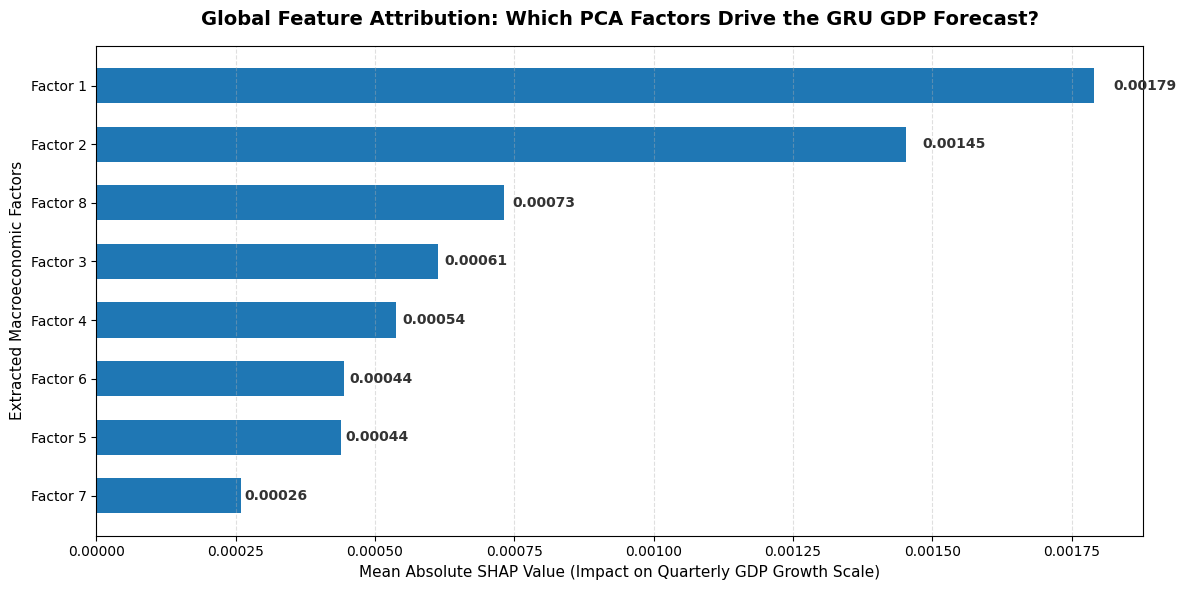

In [176]:
plt.figure(figsize=(12, 6))
bars = plt.barh(importance_df['Macroeconomic Factor'], importance_df['Absolute SHAP Impact'], color='#1f77b4', edgecolor='none', height=0.6)
plt.title('Global Feature Attribution: Which PCA Factors Drive the GRU GDP Forecast?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mean Absolute SHAP Value (Impact on Quarterly GDP Growth Scale)', fontsize=11)
plt.ylabel('Extracted Macroeconomic Factors', fontsize=11)
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
for bar in bars:
    width = bar.get_width()
    plt.text(width + (width * 0.02), bar.get_y() + bar.get_height()/2, f'{width:.5f}',
             va='center', ha='left', fontsize=10, fontweight='semibold', color='#333333')

plt.tight_layout()
plt.show()